In [3]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline

In [4]:
df = pd.read_csv('Breast_Cancer.csv')

In [5]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [6]:
df.shape

(4024, 16)

In [7]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Reginol Node Positive   4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status                  4024 non

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.Race.value_counts()

Race
White    3412
Other     320
Black     291
Name: count, dtype: int64

In [12]:
df['Marital Status'].value_counts()

Marital Status
Married      2642
Single        615
Divorced      486
Widowed       235
Separated      45
Name: count, dtype: int64

In [13]:
df['T Stage '].value_counts()

T Stage 
T2    1786
T1    1602
T3     533
T4     102
Name: count, dtype: int64

In [14]:
df['N Stage'].value_counts()

N Stage
N1    2731
N2     820
N3     472
Name: count, dtype: int64

In [15]:
df['6th Stage'].value_counts()

6th Stage
IIA     1304
IIB     1130
IIIA    1050
IIIC     472
IIIB      67
Name: count, dtype: int64

In [16]:
df.differentiate.value_counts()

differentiate
Moderately differentiated    2350
Poorly differentiated        1111
Well differentiated           543
Undifferentiated               19
Name: count, dtype: int64

In [17]:
df.Grade.value_counts()

Grade
2                        2350
3                        1111
1                         543
 anaplastic; Grade IV      19
Name: count, dtype: int64

In [18]:
df['A Stage'].value_counts()

A Stage
Regional    3931
Distant       92
Name: count, dtype: int64

In [19]:
df['Estrogen Status'].value_counts()

Estrogen Status
Positive    3754
Negative     269
Name: count, dtype: int64

In [20]:
df['Progesterone Status'].value_counts()

Progesterone Status
Positive    3325
Negative     698
Name: count, dtype: int64

In [21]:
df.Status.value_counts()

Status
Alive    3407
Dead      616
Name: count, dtype: int64

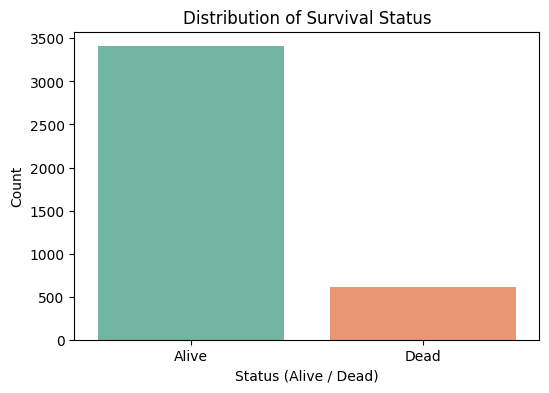

In [22]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Status', data=df, palette='Set2')
plt.title('Distribution of Survival Status')
plt.xlabel('Status (Alive / Dead)')
plt.ylabel('Count')
plt.show()

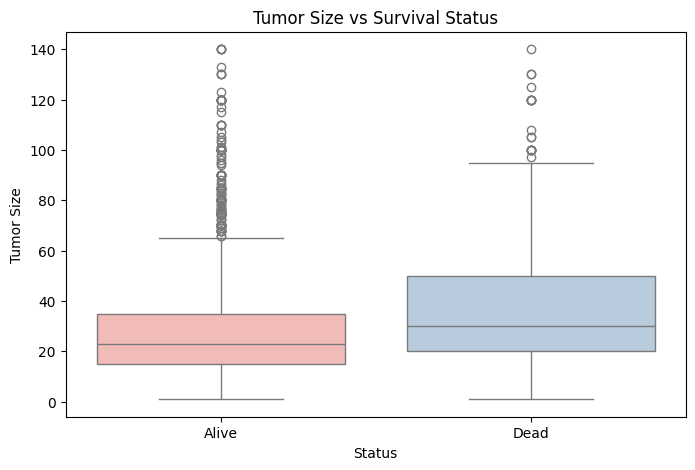

In [23]:
# Boxplot to see Tumor Size distribution across Survival Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='Status', y='Tumor Size', data=df, palette='Pastel1')
plt.title('Tumor Size vs Survival Status')
plt.show()

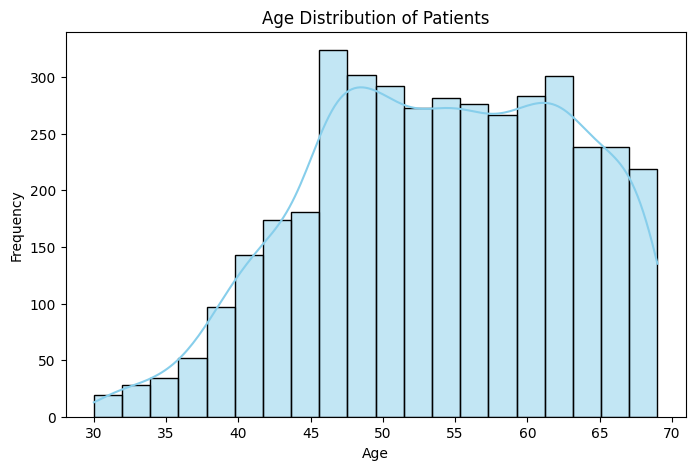

In [24]:
# Histogram for Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=20)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

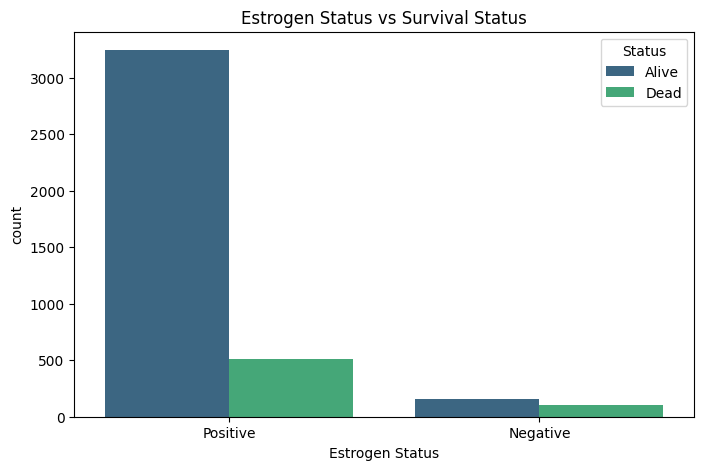

In [25]:
# Estrogen Status vs Survival Status
plt.figure(figsize=(8, 5))
sns.countplot(x='Estrogen Status', hue='Status', data=df, palette='viridis')
plt.title('Estrogen Status vs Survival Status')
plt.show()

In [26]:
la = LabelEncoder()

In [27]:
cat_cols = df.select_dtypes(include=['string','object']).columns
for col in cat_cols:
    df[col] = la.fit_transform(df[col].astype(str))

df = df.astype(int)

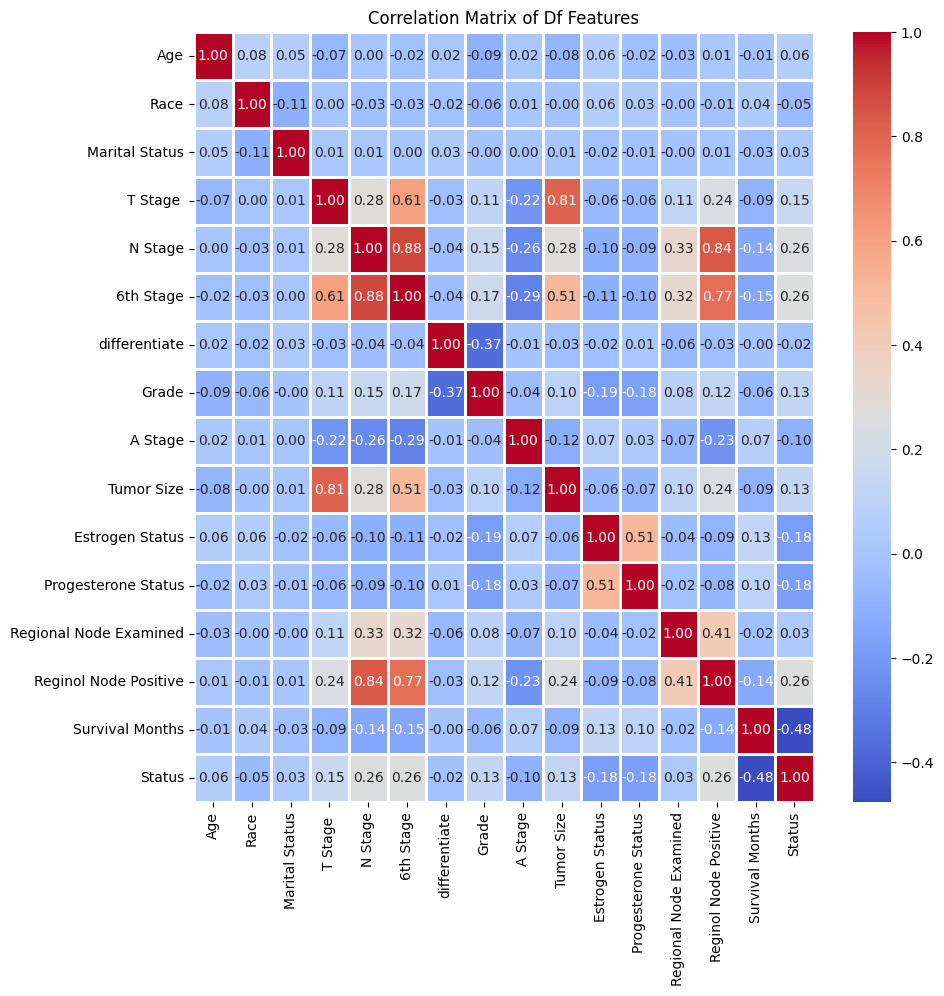

In [28]:
# Correlation Heatmap for Df Features
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.8)
plt.title('Correlation Matrix of Df Features')
plt.show()

In [29]:
x = df.drop('Status',axis=1)

In [30]:
y = df['Status']

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, shuffle =True)

In [32]:
#scaler = StandardScaler()
#x_train_scaled = scaler.fit_transform(x_train)

In [33]:
#smote = SMOTE(random_state=42)

In [34]:
#smote = SMOTE(random_state=42)
#x_train_res, y_train_res = smote.fit_resample(x_train_scaled, y_train)

In [35]:
#x_test_scaled = scaler.transform(x_test)

In [36]:
#model1= RandomForestClassifier()

In [37]:
#model2 = GradientBoostingClassifier()

In [38]:
#model3= LogisticRegression()

In [39]:
#model4 = SVC()

In [40]:
#def try_model(model):
 #   model.fit(x_train_res, y_train_res)
  #  pred = model.predict(x_test_scaled)
   # acc = accuracy_score(y_test,pred)
   # clr = classification_report(y_test,pred)
   # cm = confusion_matrix(y_test,pred)
   # print(f"accuracy score is {acc}")
   # print(f"classification report is {clr}")
   # sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
   # plt.xlabel('Predicted')
   # plt.ylabel('Actual')
   # plt.title(f'Confusion Matrix for {model.__class__.__name__}')
   # plt.show()

In [41]:
#try_model(model1)

In [42]:
#try_model(model2)

In [43]:
#try_model(model3)

In [44]:
#try_model(model4)

In [45]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(random_state=42))
])

In [46]:
param_grid = {
    'model__n_estimators': [100, 150, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 4, 5],
    'model__subsample': [0.8, 1.0]
}

In [47]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall', 
    cv=5,            
    n_jobs=-1,        
    verbose=2
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.7s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.8s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.8s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.7s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   1.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   0.7s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.7s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=150, model__subsample=0.8; total time=   1.0s
[CV] END model__learning

In [48]:
# 5. سحب أفضل موديل طلع من البحث
best_pipeline = grid_search.best_estimator_

# 6. التوقع على داتا الـ Test الخام
y_pred = best_pipeline.predict(x_test)

# 7. طباعة النتايج الحقيقية 100% بدون أي غش
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8583850931677018

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.91       678
           1       0.54      0.73      0.62       127

    accuracy                           0.86       805
   macro avg       0.74      0.81      0.77       805
weighted avg       0.88      0.86      0.87       805



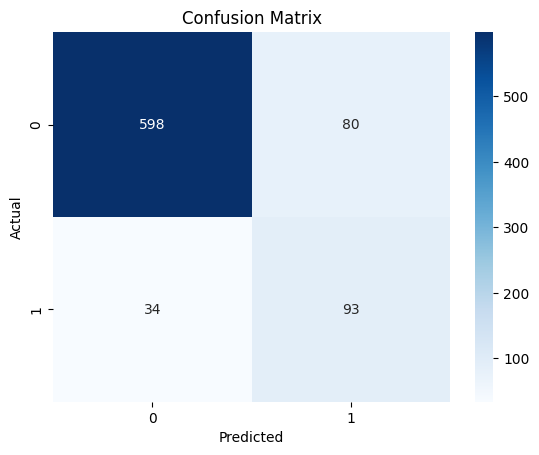

In [49]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [51]:
import pickle
with open('breast_cancer_model.sav', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)